In [2]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/Mobile Reviews_cleaned.csv")

In [4]:
df.head()

,review_id,customer_name,age,brand,model,price_usd,currency,exchange_rate_to_usd,rating,sentiment,...,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,INR,83.00,2.0,Negative,...,Hindi,2023-11-06,True,1,1,3,2,1,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,BRL,5.70,4.0,Positive,...,Portuguese,2023-03-30,True,3,2,4,3,2,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,INR,83.00,4.0,Positive,...,Hindi,2022-12-07,True,3,5,3,2,4,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,AED,3.67,3.0,Positive,...,English,2025-03-11,False,1,3,2,1,2,3,Amazon
4,5,Yago Leão,38,Motorola,Edge 50,792.13,BRL,5.70,3.0,Neutral,...,Portuguese,2023-09-29,True,3,3,2,2,1,0,BestBuy


In [5]:
df.isna().sum()

,0
review_id,0
customer_name,0
age,0
brand,0
model,0
price_usd,0
currency,0
exchange_rate_to_usd,0
rating,0
sentiment,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   review_id             50000 non-null  int64  
 1   customer_name         50000 non-null  object 
 2   age                   50000 non-null  int64  
 3   brand                 50000 non-null  object 
 4   model                 50000 non-null  object 
 5   price_usd             50000 non-null  float64
 6   currency              50000 non-null  object 
 7   exchange_rate_to_usd  50000 non-null  float64
 8   rating                50000 non-null  float64
 9   sentiment             50000 non-null  object 
 10  country               50000 non-null  object 
 11  language              50000 non-null  object 
 12  review_date           50000 non-null  object 
 13  verified_purchase     50000 non-null  bool   
 14  battery_life_rating   50000 non-null  int64  
 15  camera_rating      

In [8]:
df.describe()

,review_id,age,price_usd,exchange_rate_to_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,30.075220,689.795238,12.057946,3.117360,2.71800,2.717640,2.719620,2.713960,2.721280,3.644180
std,14433.901067,8.931307,307.305506,26.553332,1.218333,1.34827,1.345001,1.349208,1.343346,1.352121,2.432745
min,1.000000,18.000000,180.020000,0.780000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,12500.750000,23.000000,450.800000,1.000000,2.000000,1.00000,1.000000,1.000000,1.000000,1.000000,2.000000
50%,25000.500000,29.000000,640.805000,1.530000,3.000000,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,37500.250000,36.000000,901.405000,5.700000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,5.000000
max,50000.000000,65.000000,1499.890000,83.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,17.000000


In [9]:
df['review_date']

,review_date
0,2023-11-06
1,2023-03-30
2,2022-12-07
3,2025-03-11
4,2023-09-29
...,...
49995,2023-08-17
49996,2023-09-23
49997,2023-04-04
49998,2025-07-11


In [10]:
df['review_date'] = pd.to_datetime(df['review_date'])

In [11]:
df.brand.value_counts()

,count
brand,
Xiaomi,7241
Google,7234
Apple,7144
OnePlus,7136
Realme,7132
Motorola,7061
Samsung,7052


In [12]:
df.brand.unique()

array(['Realme', 'Google', 'Xiaomi', 'Motorola', 'Apple', 'OnePlus',
       'Samsung'], dtype=object)

##Rating and Sentiment

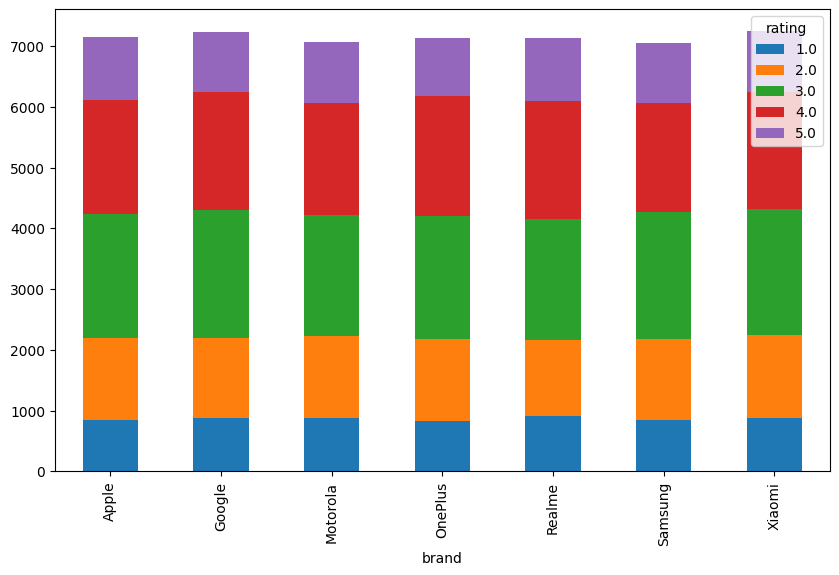

In [13]:
#Rating distribution by brand
df.groupby('brand')['rating'].value_counts().unstack().plot(kind='bar', stacked=True, figsize=(10,6))
plt.show()

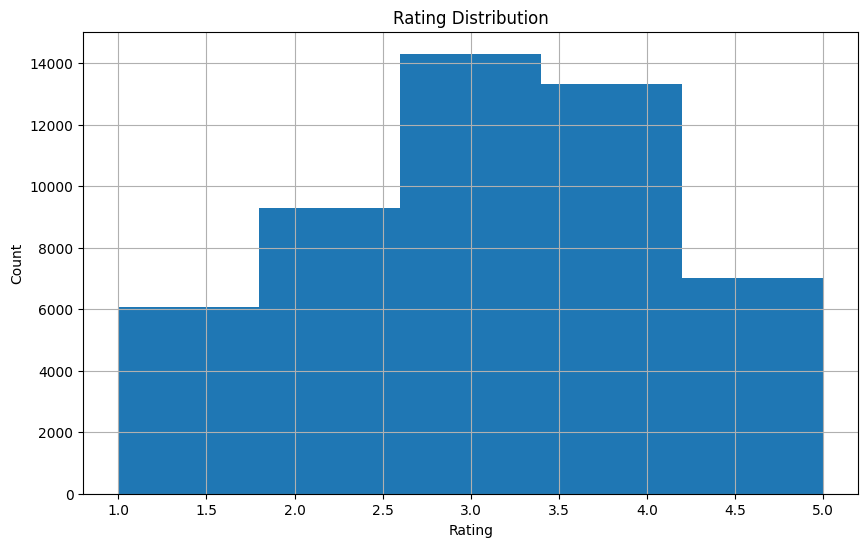

In [14]:
#overall rating distribution
df['rating'].hist(bins=5, figsize=(10,6))
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

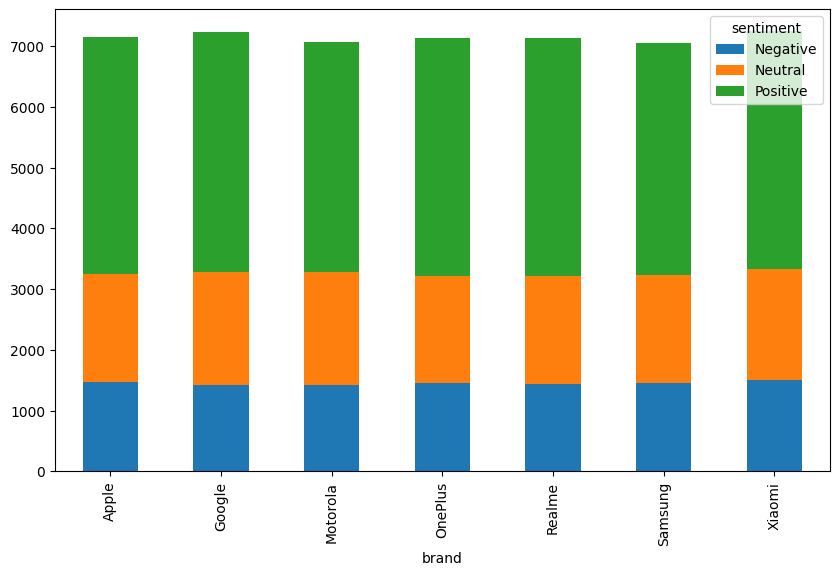

In [15]:
#Sentiment distribution across different brands
df.groupby('brand')['sentiment'].value_counts().unstack().plot(kind='bar', stacked=True, figsize=(10,6))
plt.show()

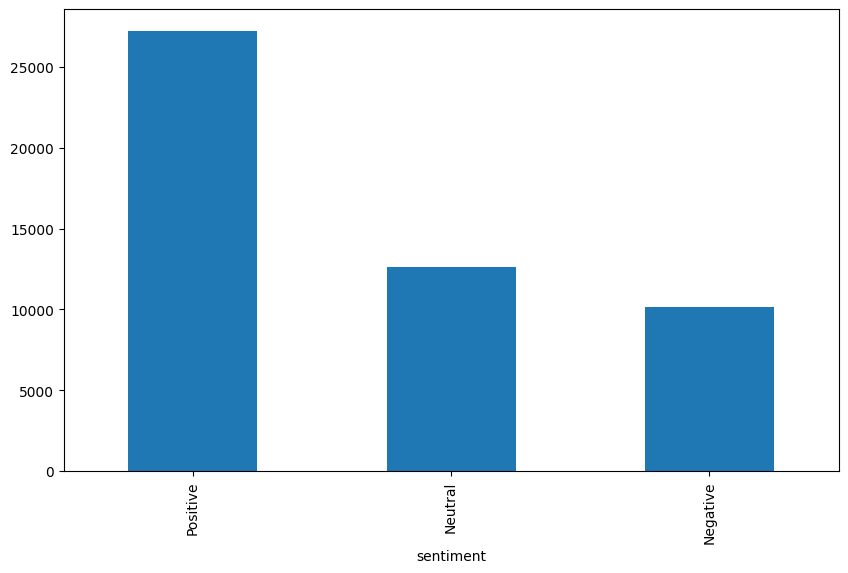

In [16]:
#overall sentiment distribution
df['sentiment'].value_counts().plot(kind='bar', figsize=(10,6))

plt.show()

In [23]:
#rating vs sentiment
pd.crosstab(df["rating"], df["sentiment"])

sentiment,Negative,Neutral,Positive
rating,,,
1.0,4804,1242,25
2.0,3939,4612,754
3.0,1360,5591,7358
4.0,54,1118,12143
5.0,0,76,6924


In [21]:
#rating vs sentiment in percetage
pd.crosstab(df["rating"],df["sentiment"],normalize="index") * 100

sentiment,Negative,Neutral,Positive
rating,,,
1.0,79.130292,20.457915,0.411794
2.0,42.332080,49.564750,8.103170
3.0,9.504508,39.073311,51.422182
4.0,0.405558,8.396545,91.197897
5.0,0.000000,1.085714,98.914286


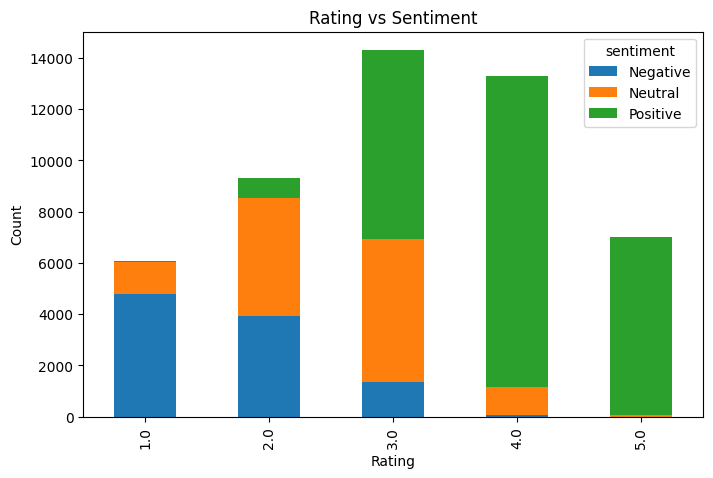

In [24]:
pd.crosstab(df["rating"], df["sentiment"]).plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Rating vs Sentiment")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

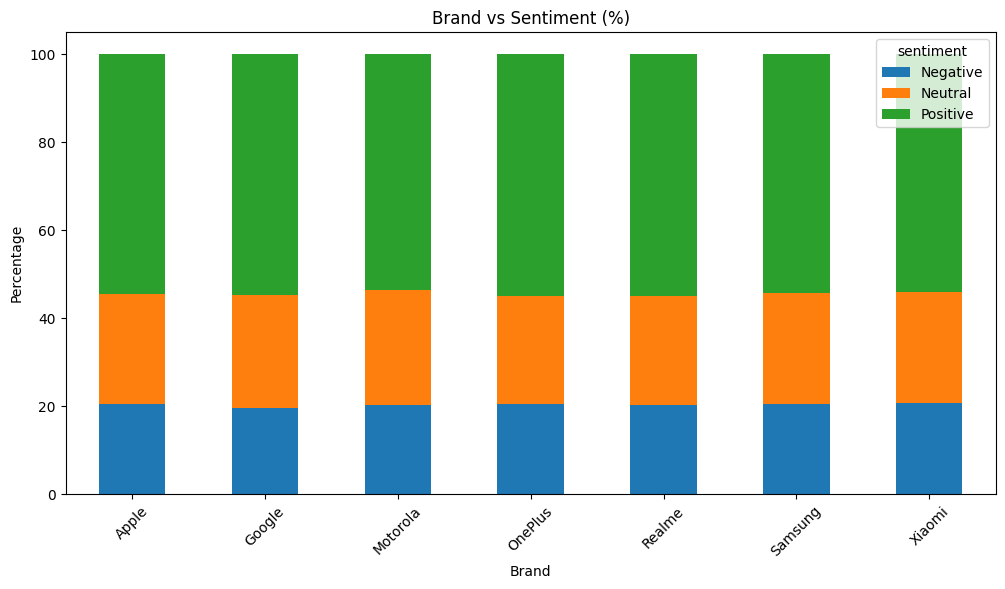

In [25]:
#brandwise vs sentiment
pd.crosstab(df["brand"], df["sentiment"], normalize="index").mul(100).plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Brand vs Sentiment (%)")
plt.xlabel("Brand")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

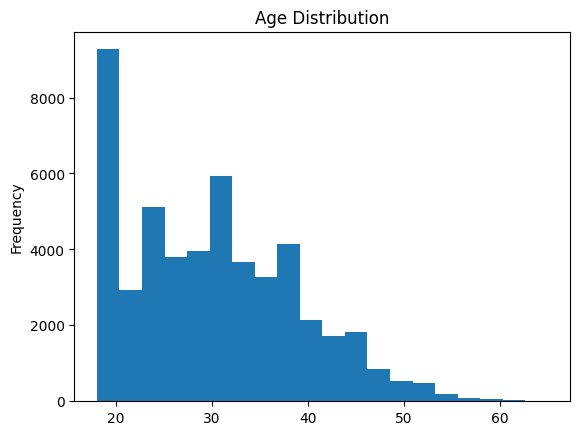

In [26]:
#age wise reviewers
df["age"].plot(kind="hist", bins=20)
plt.title("Age Distribution")
plt.show()

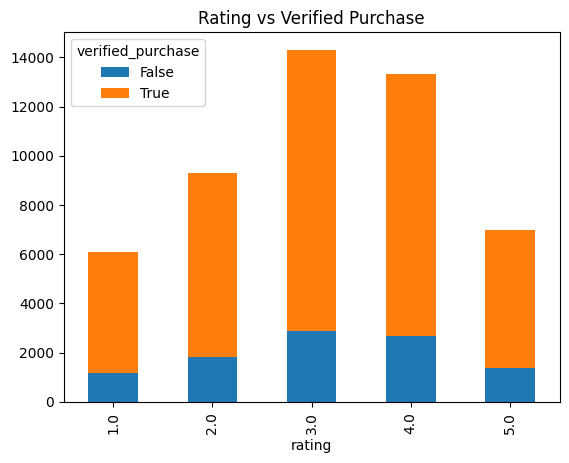

In [28]:
#ratinng from verified purchase
pd.crosstab(df["rating"], df["verified_purchase"]).plot(
    kind="bar",
    stacked=True
)

plt.title("Rating vs Verified Purchase")
plt.show()

In [30]:
df.model.value_counts()

,count
model,
Realme Narzo 70,3597
Realme 12 Pro,3535
Redmi Note 13,2470
Pixel 7a,2468
Mi 13 Pro,2445
OnePlus 11R,2433
Razr 40,2395
Pixel 8,2387
OnePlus Nord 3,2380


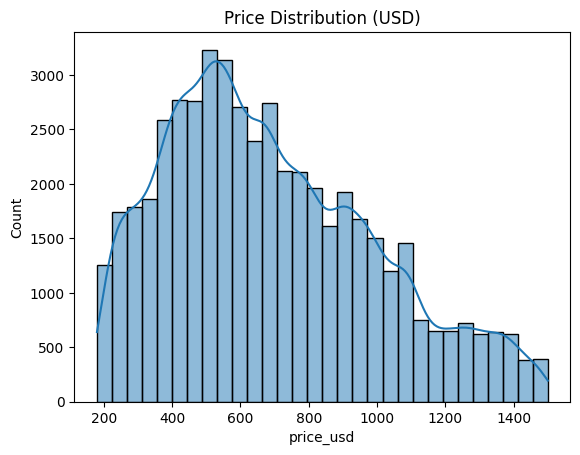

In [22]:
#Price distribution
sns.histplot(df["price_usd"], bins=30, kde=True)
plt.title("Price Distribution (USD)")
plt.show()

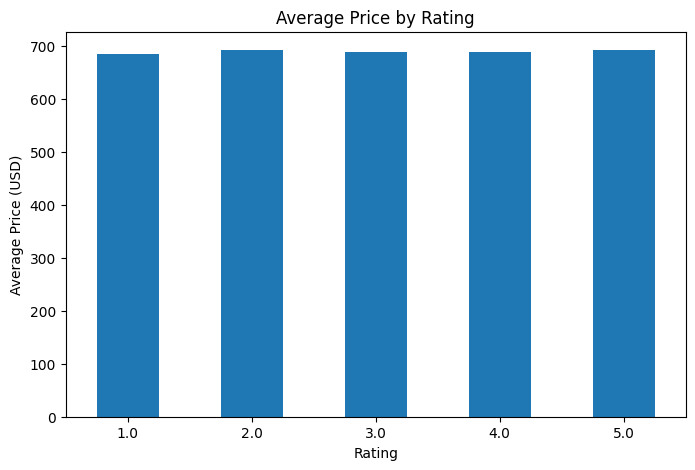

In [34]:
df.groupby("rating")["price_usd"].mean().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=0)
plt.show()

##product wise Analysis

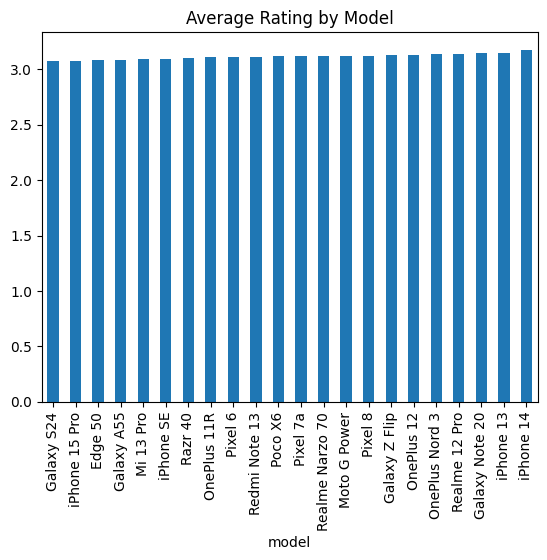

In [56]:
#average rating by model
df.groupby("model")["rating"].mean().sort_values().plot(kind="bar")
plt.title("Average Rating by Model")
plt.show()

In [42]:
#top low rated models
df.groupby("model")["rating"].mean().sort_values(ascending=False).head(10)

,rating
model,
iPhone 14,3.176174
iPhone 13,3.150538
Galaxy Note 20,3.144215
Realme 12 Pro,3.140594
OnePlus Nord 3,3.136555
OnePlus 12,3.128713
Galaxy Z Flip,3.128355
Pixel 8,3.122748
Moto G Power,3.122501


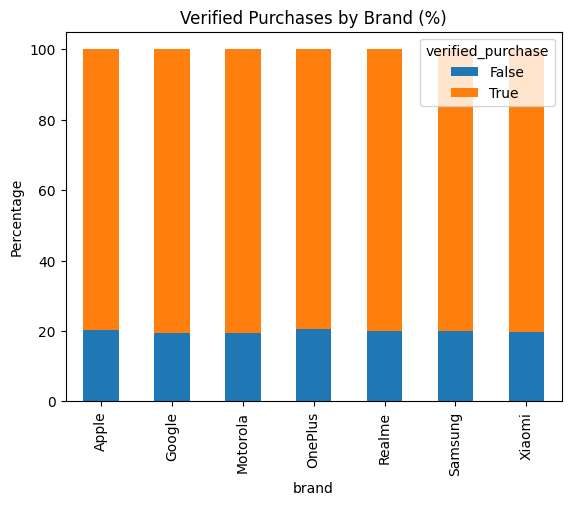

In [57]:
#brand wise verified purchase
pd.crosstab(
    df["brand"],
    df["verified_purchase"],
    normalize="index"
).mul(100).plot(kind="bar", stacked=True)

plt.title("Verified Purchases by Brand (%)")
plt.ylabel("Percentage")
plt.show()

In [46]:
#correlation with ratings
corr = df[[
    "price_usd",
    "rating",
    "battery_life_rating",
    "camera_rating",
    "performance_rating",
    "design_rating",
    "display_rating",
    "helpful_votes"
]].corr()

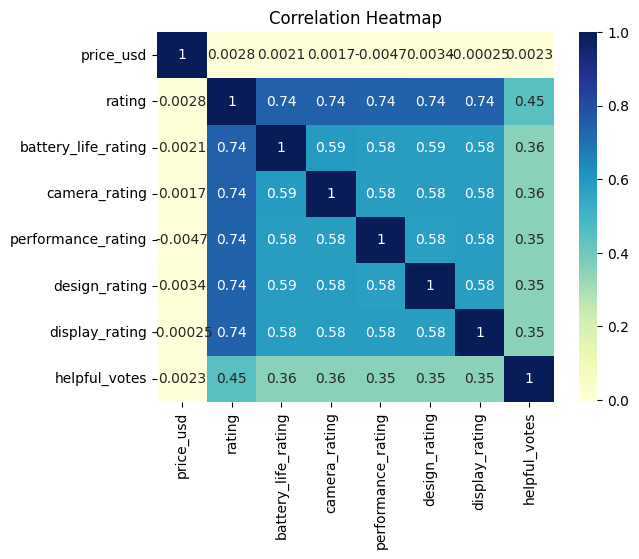

In [49]:
sns.heatmap(corr, annot=True, cmap="YlGnBu")
plt.title("Correlation Heatmap")
plt.show()


In [66]:
df.head()

,review_id,customer_name,age,brand,model,price_usd,currency,exchange_rate_to_usd,rating,sentiment,...,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source,price_range,positive_sentiment
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,INR,83.00,2.0,Negative,...,True,1,1,3,2,1,1,Amazon,"(312.007, 443.994]",False
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,BRL,5.70,4.0,Positive,...,True,3,2,4,3,2,5,Flipkart,"(178.7, 312.007]",True
2,3,Pahal Balay,27,Google,Pixel 6,864.53,INR,83.00,4.0,Positive,...,True,3,5,3,2,4,8,AliExpress,"(839.955, 971.942]",True
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,AED,3.67,3.0,Positive,...,False,1,3,2,1,2,3,Amazon,"(575.981, 707.968]",True
4,5,Yago Leão,38,Motorola,Edge 50,792.13,BRL,5.70,3.0,Neutral,...,True,3,3,2,2,1,0,BestBuy,"(707.968, 839.955]",False


In [62]:
#create a new dataframe to check average of everything by brand and model
df["positive_sentiment"] = df["sentiment"] == "Positive"
product_mean = df.groupby(["brand", "model"]).agg({
    "price_usd": "median",
    "rating": "mean",
    "battery_life_rating": "mean",
    "camera_rating": "mean",
    "performance_rating": "mean",
    "design_rating": "mean",
    "display_rating": "mean",
    "verified_purchase": "mean",
    "review_id": "count",
    "positive_sentiment": "mean",
}).reset_index()

#boolean value columns when converted to mean, changes into numbers 1 and 0 and the average is given as percentage

In [63]:
product_mean.shape

,brand,model,price_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,verified_purchase,review_id,positive_sentiment
0,Apple,iPhone 13,1106.38,3.150538,2.754952,2.754952,2.765139,2.765139,2.710243,0.795133,1767,0.562535
1,Apple,iPhone 14,1094.51,3.176174,2.738255,2.781879,2.723714,2.773490,2.758949,0.815436,1788,0.558725
2,Apple,iPhone 15 Pro,1102.27,3.079197,2.677635,2.707195,2.661461,2.675404,2.691021,0.785276,1793,0.526492
3,Apple,iPhone SE,1101.03,3.096882,2.727728,2.703786,2.732183,2.690980,2.735523,0.796214,1796,0.535078
4,Google,Pixel 6,808.53,3.112232,2.712064,2.709962,2.689786,2.706179,2.715427,0.800336,2379,0.552333
5,Google,Pixel 7a,809.44,3.119530,2.715964,2.732172,2.725689,2.721232,2.748784,0.798217,2468,0.544165
6,Google,Pixel 8,799.52,3.122748,2.731881,2.715543,2.691244,2.743611,2.737746,0.820695,2387,0.541684
7,Motorola,Edge 50,514.92,3.087257,2.674730,2.701512,2.704536,2.688553,2.707559,0.803024,2315,0.530454
8,Motorola,Moto G Power,505.34,3.122501,2.715015,2.706083,2.716291,2.716291,2.719268,0.817950,2351,0.548703
9,Motorola,Razr 40,511.44,3.103967,2.713152,2.683925,2.730271,2.724843,2.724008,0.799165,2395,0.525261


In [64]:
product_mean.head(10)

,brand,model,price_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,verified_purchase,review_id,positive_sentiment
0,Apple,iPhone 13,1106.38,3.150538,2.754952,2.754952,2.765139,2.765139,2.710243,0.795133,1767,0.562535
1,Apple,iPhone 14,1094.51,3.176174,2.738255,2.781879,2.723714,2.773490,2.758949,0.815436,1788,0.558725
2,Apple,iPhone 15 Pro,1102.27,3.079197,2.677635,2.707195,2.661461,2.675404,2.691021,0.785276,1793,0.526492
3,Apple,iPhone SE,1101.03,3.096882,2.727728,2.703786,2.732183,2.690980,2.735523,0.796214,1796,0.535078
4,Google,Pixel 6,808.53,3.112232,2.712064,2.709962,2.689786,2.706179,2.715427,0.800336,2379,0.552333
5,Google,Pixel 7a,809.44,3.119530,2.715964,2.732172,2.725689,2.721232,2.748784,0.798217,2468,0.544165
6,Google,Pixel 8,799.52,3.122748,2.731881,2.715543,2.691244,2.743611,2.737746,0.820695,2387,0.541684
7,Motorola,Edge 50,514.92,3.087257,2.674730,2.701512,2.704536,2.688553,2.707559,0.803024,2315,0.530454
8,Motorola,Moto G Power,505.34,3.122501,2.715015,2.706083,2.716291,2.716291,2.719268,0.817950,2351,0.548703
9,Motorola,Razr 40,511.44,3.103967,2.713152,2.683925,2.730271,2.724843,2.724008,0.799165,2395,0.525261


In [65]:
product_mean = product_mean.rename(columns={"review_id": "review_counts"})

print(product_mean.shape)
product_mean.head(10)

(22, 12)


,brand,model,price_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,verified_purchase,review_counts,positive_sentiment
0,Apple,iPhone 13,1106.38,3.150538,2.754952,2.754952,2.765139,2.765139,2.710243,0.795133,1767,0.562535
1,Apple,iPhone 14,1094.51,3.176174,2.738255,2.781879,2.723714,2.773490,2.758949,0.815436,1788,0.558725
2,Apple,iPhone 15 Pro,1102.27,3.079197,2.677635,2.707195,2.661461,2.675404,2.691021,0.785276,1793,0.526492
3,Apple,iPhone SE,1101.03,3.096882,2.727728,2.703786,2.732183,2.690980,2.735523,0.796214,1796,0.535078
4,Google,Pixel 6,808.53,3.112232,2.712064,2.709962,2.689786,2.706179,2.715427,0.800336,2379,0.552333
5,Google,Pixel 7a,809.44,3.119530,2.715964,2.732172,2.725689,2.721232,2.748784,0.798217,2468,0.544165
6,Google,Pixel 8,799.52,3.122748,2.731881,2.715543,2.691244,2.743611,2.737746,0.820695,2387,0.541684
7,Motorola,Edge 50,514.92,3.087257,2.674730,2.701512,2.704536,2.688553,2.707559,0.803024,2315,0.530454
8,Motorola,Moto G Power,505.34,3.122501,2.715015,2.706083,2.716291,2.716291,2.719268,0.817950,2351,0.548703
9,Motorola,Razr 40,511.44,3.103967,2.713152,2.683925,2.730271,2.724843,2.724008,0.799165,2395,0.525261


##Sanity checks on the product_mean table on all aggregated values

In [58]:
product_mean[["rating", "battery_life_rating", "camera_rating",
                   "performance_rating", "design_rating", "display_rating"]].std()

,0
rating,0.024880
battery_life_rating,0.020702
camera_rating,0.026468
performance_rating,0.034999
design_rating,0.030079
display_rating,0.026303


In [59]:
#check on non aggregated df
df[["rating", "battery_life_rating", "camera_rating",
           "performance_rating", "design_rating", "display_rating"]].std()

,0
rating,1.218333
battery_life_rating,1.348270
camera_rating,1.345001
performance_rating,1.349208
design_rating,1.343346
display_rating,1.352121


In [68]:
product_mean[["positive_sentiment", "verified_purchase", "review_counts"]].describe()

,positive_sentiment,verified_purchase,review_counts
count,22.000000,22.000000,22.000000
mean,0.543838,0.801236,2272.727273
std,0.010540,0.009181,513.376051
min,0.525261,0.783039,1714.000000
25%,0.536699,0.797208,1790.000000
50%,0.544552,0.799751,2338.500000
75%,0.548932,0.803607,2423.500000
max,0.562535,0.820695,3597.000000


##Price Segmentation

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

In [77]:
scaler = StandardScaler()
price_scaled = scaler.fit_transform(product_mean[["price_usd"]])

k=1, inertia=22.00
k=2, inertia=4.65
k=3, inertia=1.87
k=4, inertia=0.56
k=5, inertia=0.29
k=6, inertia=0.07


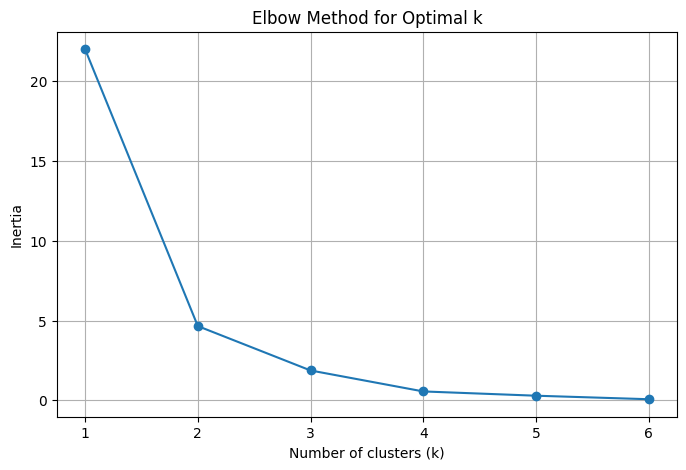

In [78]:
cluster_inertia = []
k_range = range(1, 7)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(price_scaled)
    cluster_inertia.append(kmeans.inertia_)
    print(f"k={k}, inertia={kmeans.inertia_:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(k_range, cluster_inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [80]:
#creating K-Means model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

#assigning each product to a cluster
product_mean["cluster"] = kmeans.fit_predict(price_scaled)

In [81]:
cluster_summary = product_mean.groupby("cluster")["price_usd"].agg(
    ["mean", "min", "max", "count"])

cluster_summary

,mean,min,max,count
cluster,,,,
0,458.3950,392.820,514.92,8
1,803.0335,667.025,908.74,10
2,1101.0475,1094.510,1106.38,4


In [82]:
#checkng produts and clusters
product_mean[["brand", "model", "price_usd", "cluster"]].sort_values("price_usd")

,brand,model,price_usd,cluster
14,Realme,Realme Narzo 70,392.820,0
13,Realme,Realme 12 Pro,396.410,0
19,Xiaomi,Mi 13 Pro,443.830,0
21,Xiaomi,Redmi Note 13,450.800,0
20,Xiaomi,Poco X6,451.600,0
8,Motorola,Moto G Power,505.340,0
9,Motorola,Razr 40,511.440,0
7,Motorola,Edge 50,514.920,0
10,OnePlus,OnePlus 11R,667.025,1
11,OnePlus,OnePlus 12,668.090,1


##Labeling clusters to made it readable

In [83]:
segment_mapping = {0: "Budget", 1: "Mid-range", 2: "Premium"}
product_mean["segment"] = product_mean["cluster"].map(segment_mapping)

product_mean[["brand", "model", "price_usd", "cluster", "segment"]].sort_values("price_usd")

,brand,model,price_usd,cluster,segment
14,Realme,Realme Narzo 70,392.820,0,Budget
13,Realme,Realme 12 Pro,396.410,0,Budget
19,Xiaomi,Mi 13 Pro,443.830,0,Budget
21,Xiaomi,Redmi Note 13,450.800,0,Budget
20,Xiaomi,Poco X6,451.600,0,Budget
8,Motorola,Moto G Power,505.340,0,Budget
9,Motorola,Razr 40,511.440,0,Budget
7,Motorola,Edge 50,514.920,0,Budget
10,OnePlus,OnePlus 11R,667.025,1,Mid-range
11,OnePlus,OnePlus 12,668.090,1,Mid-range


##Visualization

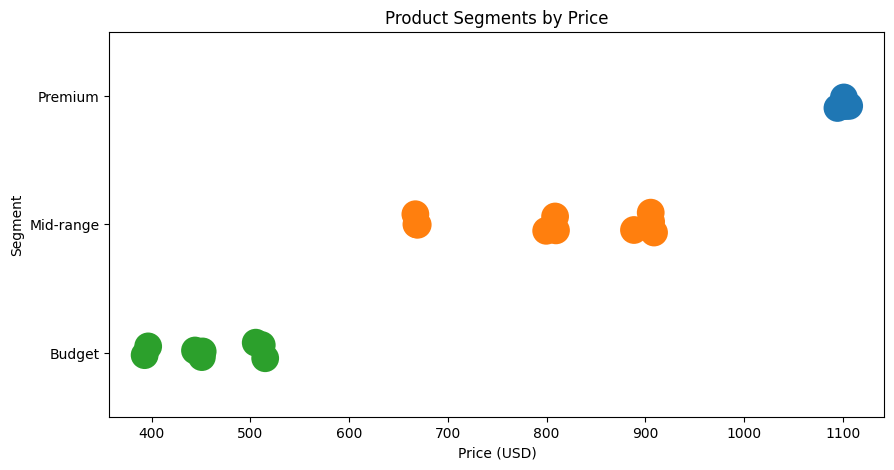

In [90]:
plt.figure(figsize=(10, 5))
sns.stripplot(data=product_mean, x="price_usd", y="segment", hue="segment", size=20, jitter=True)
plt.title("Product Segments by Price")
plt.xlabel("Price (USD)")
plt.ylabel("Segment")
plt.show()

#Recommendation based on features

In [91]:
brand_enc = pd.get_dummies(product_mean["brand"], prefix="brand")

In [95]:
num_features = product_mean[[
    "price_usd", "rating", "battery_life_rating",
    "camera_rating", "performance_rating",
    "design_rating", "display_rating",
    "positive_sentiment", "verified_purchase",
]]

In [97]:
scaler_rec = StandardScaler()
num_scaled = scaler_rec.fit_transform(num_features)
num_scaled_df = pd.DataFrame(num_scaled, columns=num_features.columns, index=product_mean.index)

In [98]:
recommendation_features = pd.concat([num_scaled_df, brand_enc], axis=1)

print(recommendation_features.shape)
recommendation_features.head()

(22, 16)


,price_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,positive_sentiment,verified_purchase,brand_Apple,brand_Google,brand_Motorola,brand_OnePlus,brand_Realme,brand_Samsung,brand_Xiaomi
0,1.537585,1.388969,1.844734,1.441951,1.391390,1.753676,-0.347803,1.815649,-0.680458,True,False,False,False,False,False,False
1,1.488848,2.443625,1.019224,2.483244,0.179942,2.037855,1.547464,1.445615,1.583134,True,False,False,False,False,False,False
2,1.520710,-1.545867,-1.977878,-0.404846,-1.640591,-1.299817,-1.095817,-1.684456,-1.779398,True,False,False,False,False,False,False
3,1.515618,-0.818333,0.498771,-0.536653,0.427612,-0.769807,0.635920,-0.850684,-0.559959,True,False,False,False,False,False,False
4,0.314654,-0.186858,-0.275692,-0.297824,-0.812262,-0.252610,-0.146105,0.824909,-0.100348,False,True,False,False,False,False,False


##Similarity matrix

In [99]:
similarity_matrix = cosine_similarity(recommendation_features)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=product_df["model"],
    columns=product_df["model"],
)
similarity_df.round(2)

model,iPhone 13,iPhone 14,iPhone 15 Pro,iPhone SE,Pixel 6,Pixel 7a,Pixel 8,Edge 50,Moto G Power,Razr 40,...,OnePlus Nord 3,Realme 12 Pro,Realme Narzo 70,Galaxy A55,Galaxy Note 20,Galaxy S24,Galaxy Z Flip,Mi 13 Pro,Poco X6,Redmi Note 13
model,,,,,,,,,,,,,,,,,,,,,
iPhone 13,1.00,0.73,-0.44,0.02,-0.09,0.26,0.04,-0.83,-0.21,-0.53,...,0.31,0.34,0.10,-0.32,0.80,-0.65,0.46,-0.72,0.07,-0.20
iPhone 14,0.73,1.00,-0.55,-0.16,-0.10,0.43,0.50,-0.69,0.14,-0.55,...,0.36,0.34,0.11,-0.50,0.72,-0.77,0.42,-0.69,0.07,-0.10
iPhone 15 Pro,-0.44,-0.55,1.00,0.49,0.27,-0.15,-0.42,0.59,-0.49,0.20,...,-0.50,-0.71,-0.59,0.47,-0.64,0.84,-0.25,0.48,-0.31,-0.30
iPhone SE,0.02,-0.16,0.49,1.00,-0.06,0.19,-0.14,0.01,-0.47,0.18,...,-0.09,-0.31,-0.20,0.09,-0.04,0.25,0.29,-0.08,-0.28,-0.52
Pixel 6,-0.09,-0.10,0.27,-0.06,1.00,0.20,0.15,0.04,0.01,-0.36,...,0.06,-0.20,-0.48,0.38,-0.31,0.36,-0.13,0.40,-0.60,-0.09
Pixel 7a,0.26,0.43,-0.15,0.19,0.20,1.00,0.23,-0.27,-0.26,-0.13,...,0.23,0.35,0.14,-0.67,0.28,-0.43,0.49,-0.35,0.08,-0.45
Pixel 8,0.04,0.50,-0.42,-0.14,0.15,0.23,1.00,-0.23,0.54,-0.04,...,-0.05,-0.01,0.05,0.02,0.28,-0.30,-0.17,-0.28,0.05,0.19
Edge 50,-0.83,-0.69,0.59,0.01,0.04,-0.27,-0.23,1.00,0.22,0.61,...,-0.45,-0.39,-0.20,0.31,-0.76,0.69,-0.46,0.60,0.11,0.18
Moto G Power,-0.21,0.14,-0.49,-0.47,0.01,-0.26,0.54,0.22,1.00,0.16,...,0.14,0.20,0.19,0.09,0.01,-0.19,-0.27,0.08,0.12,0.57


In [100]:
#fucntion for recommendation
def recommend_similar_phones(model_name, top_n=3):
    similar_scores = similarity_df.loc[model_name]
    similar_scores = similar_scores.sort_values(ascending=False)
    similar_scores = similar_scores.drop(model_name)  # exclude the phone itself
    return similar_scores.head(top_n)


print(recommend_similar_phones("iPhone 13"))
print(recommend_similar_phones("Redmi Note 13"))

model
Galaxy Note 20    0.799129
iPhone 14         0.729103
Galaxy Z Flip     0.461220
Name: iPhone 13, dtype: float64
model
Moto G Power    0.569143
Poco X6         0.403993
Mi 13 Pro       0.381360
Name: Redmi Note 13, dtype: float64


In [101]:
product_mean.to_csv("product_segments.csv", index=False)
similarity_df.to_csv("similarity_mx.csv", index=False)